# Apo reconstruction with direct methods in quantem 

Notebook from Georgios Varnavides and Stephanie Ribet

Data from Berk's paper

In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import numpy as np

import quantem as em
from quantem.core import config
from quantem.core.visualization import show_2d
import h5py
config.set_device(0)
print(config.get("device"))

/home/sribet/micromamba/envs/quantem/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda:0


# load data

In [3]:
file_data = '/media/NAS-NCEM_Data/UserData/Steph Ribet/251120_Berk/pos_91_dataset.h5'

def print_h5_structure(f, indent=0):
    """Recursively print HDF5 file structure."""
    for key in f.keys():
        print('  ' * indent + key)
        if isinstance(f[key], h5py.Group):
            print_h5_structure(f[key], indent + 1)
        else:
            print('  ' * (indent + 1) + f"shape: {f[key].shape}, dtype: {f[key].dtype}")

with h5py.File(file_data, 'r') as f:
    print_h5_structure(f)

data
  shape: (128, 128, 256, 256), dtype: float32
vacuumProbe
  shape: (256, 256), dtype: float64


In [4]:
with h5py.File(file_data, 'r') as f:
    data = f['data'][:]

In [5]:
dc = em.core.datastructures.Dataset4dstem.from_array(array = data)

In [6]:
# calibrations
PROBE_SEMIANGLE = 4
ENERGY = 300e3
SAMPLING = 20

In [7]:
# bin data
dc.bin(2, axes= (2,3), modify_in_place=True)
# dc.crop(((0, 96),(0,96)), axes = (0,1), modify_in_place=True)

# calibrate

In [8]:
dc.get_dp_mean()

Dataset(shape=(128, 128), dtype=float32, name='4D-STEM dataset_dp_mean')
  sampling: [2. 2.]
  units: ['pixels', 'pixels']
  signal units: 'arb. units'

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

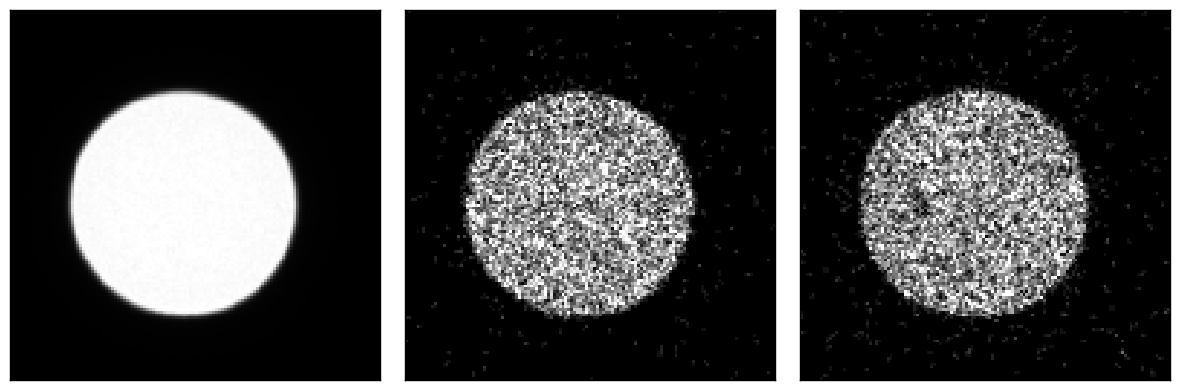

In [9]:
em.visualization.show_2d(
    [
        dc.dp_mean,
        dc.array[30,30],
        dc.array[15,15]
    ]
)

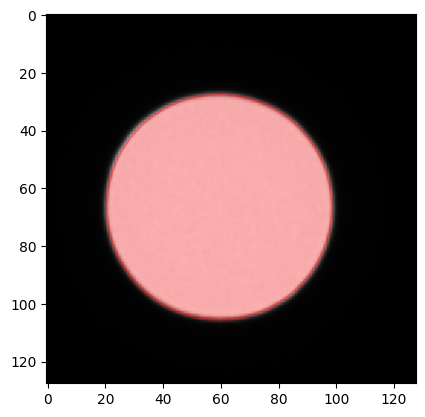

In [10]:
from quantem.core.utils.diffractive_imaging_utils import fit_probe_circle
probe_qy0, probe_qx0, probe_R = fit_probe_circle(dc.dp_mean.array, show=True)
dc.sampling[2] = PROBE_SEMIANGLE / probe_R
dc.sampling[3] = PROBE_SEMIANGLE / probe_R
dc.units[2:] = ["mrad", "mrad"]


dc.sampling[0] = SAMPLING
dc.sampling[1] = SAMPLING
dc.units[0:2] = ["A", "A"]


# print(dc)

# direct ptycho

In [11]:
direct_ptycho = em.diffractive_imaging.direct_ptychography.DirectPtychography.from_dataset4d(
    dc,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    aberration_coefs={'C10':10}, # start close to focus
    device="cpu",
    rotation_angle=np.deg2rad(0), # known rotation
    max_batch_size=32
)

# todo: I don't like that direct ptycho uses angles in rad and iterative uses it in angles. I would prefer to have everything in angles. 



# direct ptycho: optimize

In [12]:
# solve for parameters 
# todo some kind of wrapper to make this more user friendly. I have suggestions but happy to hear what everyone else suggests too.

from quantem.diffractive_imaging.direct_ptychography import OptimizationParameter
direct_ptycho.optimize_hyperparameters(
    aberration_coefs={
        "C10":OptimizationParameter(-20000,20000),
        "C12":OptimizationParameter(0, 100),
        "phi12":OptimizationParameter(-np.pi/2, np.pi/2)
    },
    rotation_angle=OptimizationParameter(np.deg2rad(-180),np.deg2rad(0)),
    deconvolution_kernel='quadratic',
)



Best trial: 23. Best value: 0.101092: 100%|█████| 50/50 [01:08<00:00,  1.37s/it]


Optimized parameters: {'C10': 17033.78652167664, 'C12': 27.783977876812482, 'phi12': -0.8777804375075192, 'rotation_angle': -1.5977369546774955}


In [13]:
np.rad2deg(-1.5999)

np.float64(-91.66751764298041)

100%|███████████████████████████████████████| 4792/4792 [01:50<00:00, 43.43it/s]


(<Figure size 400x400 with 1 Axes>, <Axes: >)

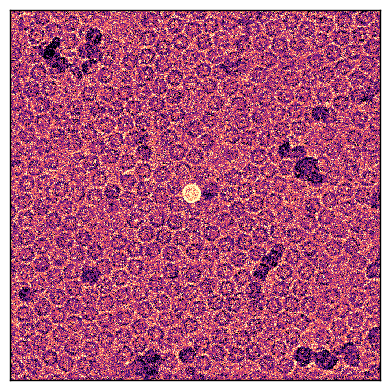

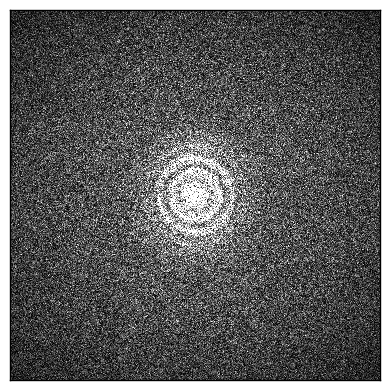

In [14]:
initial_parallax = direct_ptycho.reconstruct_with_optimized_parameters(
    upsampling_factor = 5,
    max_batch_size = 100
)

show_2d(initial_parallax.obj, cmap = "magma")


show_2d(np.fft.fftshift(np.abs(np.fft.fft2(initial_parallax.obj))))

In [15]:
from quantem.core.datastructures import Dataset4dstem
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.ptychography_lite import PtychoLite, PtychoLiteDIP

Forcing best fit rotation to -90 degrees.
Forcing transpose of intensities to False.


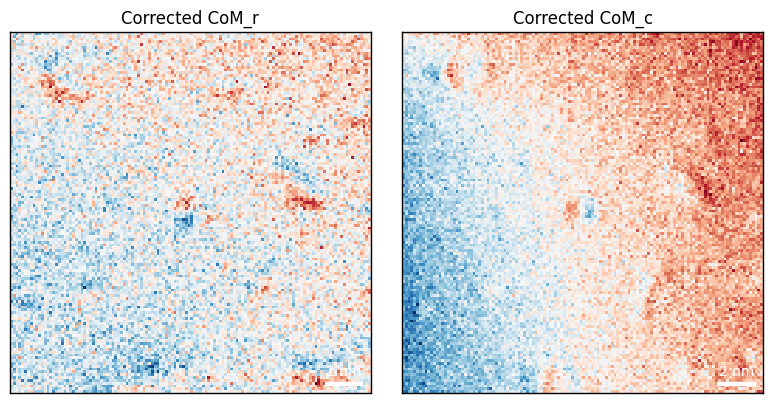

Normalizing intensities: 100%|█| 16384/16384 [00:14<00:00, 1135.80probe position


In [16]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dc)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
    probe_energy=ENERGY,
    force_com_rotation=-90,
    force_com_transpose = False,
)


In [17]:
ptycho_pix = PtychoLite.from_dataset(
    dset=pdset,
    num_slices=1,
    obj_type="pure_phase",
    num_probes=1,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    obj_padding_px=(48,48),
    device="cpu",
    polar_parameters = {'C10': 13700}
)

Iter 100/100, Loss: 1.171e+03: 100%|██████████| 100/100 [01:21<00:00,  1.23it/s]


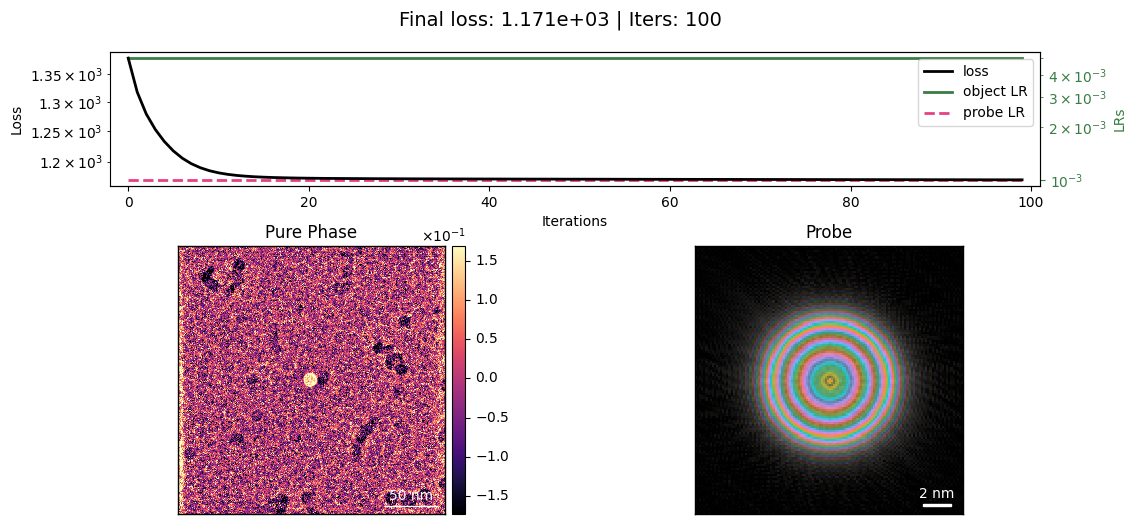

In [18]:
constraints = {
    "object":{
        "fix_potential_baseline": False,
        # "fix_potential_baseline_factor": 0.5,
        # "tv_weight_yx": 10,
        # "positivity": False,
        "q_lowpass": 1.5,
    }
}
ptycho_pix.reconstruct(
    num_iters=100, 
    device="gpu", 
    batch_size=1024,
    # constraints=constraints,
    reset = True,
).visualize()


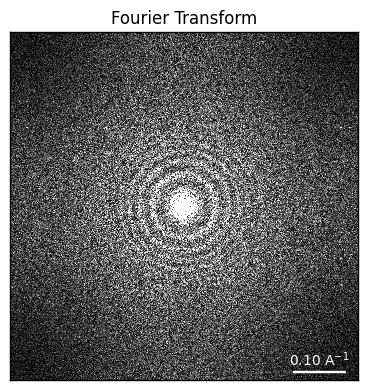

In [19]:
ptycho_pix.show_obj_fft()

Iter 150/150, Loss: 1.658e-03, : 100%|████████| 150/150 [00:39<00:00,  3.78it/s]


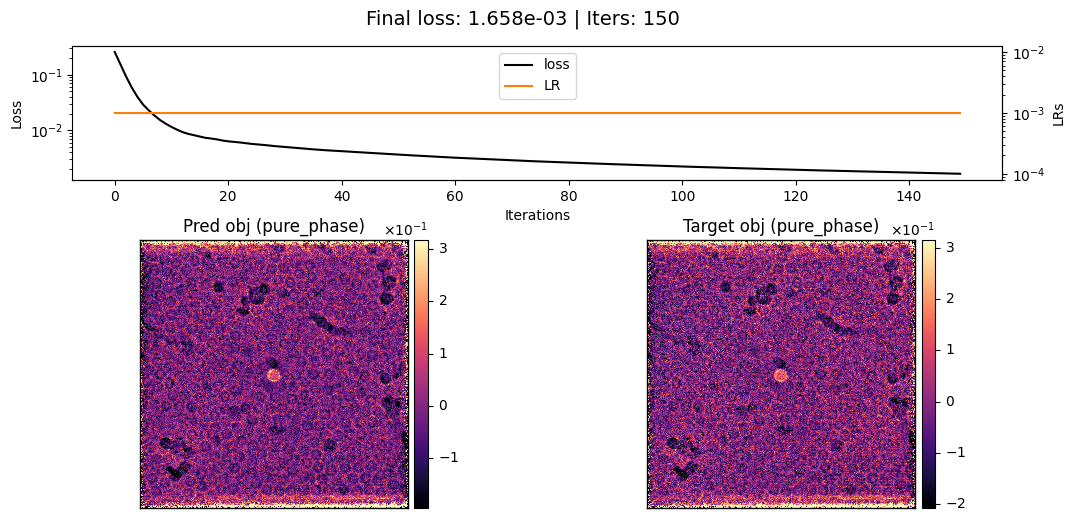

Iter 150/150, Loss: 1.074e-03, : 100%|████████| 150/150 [00:09<00:00, 15.79it/s]


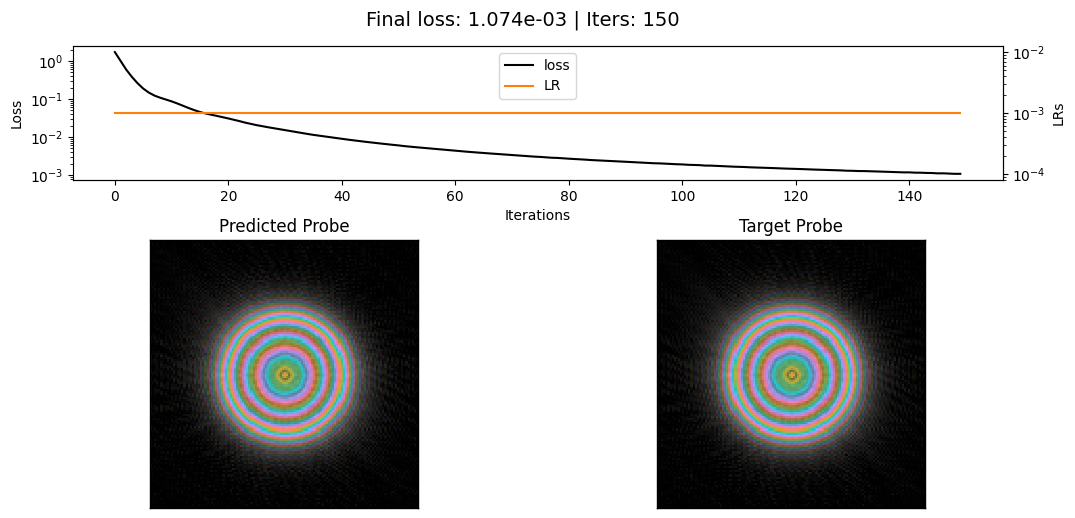

In [20]:
ptycho_dip = PtychoLiteDIP.from_ptycholite(
    ptycholite=ptycho_pix,
    pretrain_iters=150,
    device='gpu',
    # pretrain_object=False,
)

Iter 20/20, Loss: 1.175e+03: 100%|██████████████| 20/20 [02:08<00:00,  6.42s/it]


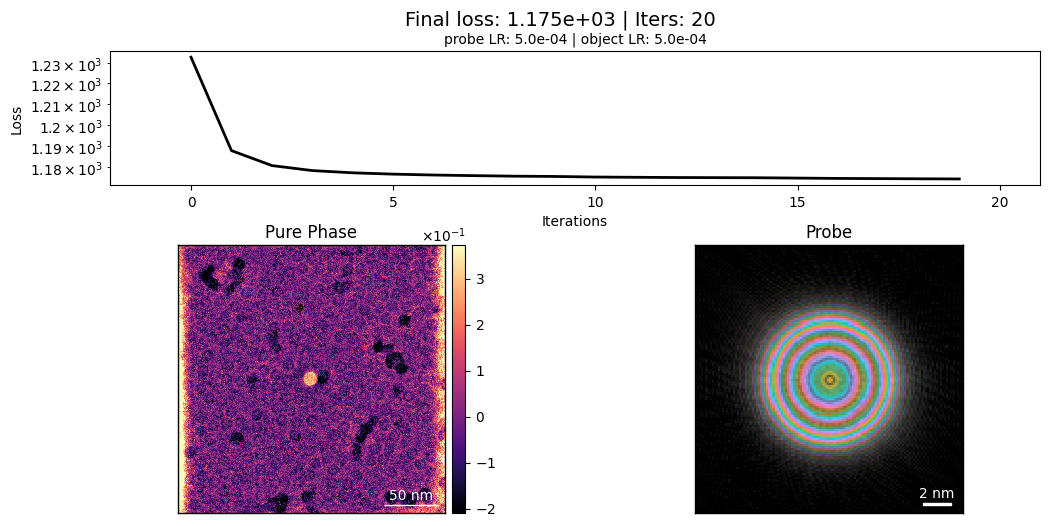

In [21]:
ptycho_dip.reconstruct(num_iters=20, reset=True, scheduler_type='plateau', batch_size=1024).visualize()


(<Figure size 1200x1200 with 4 Axes>,
 array([[<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>],
        [<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>]], dtype=object))

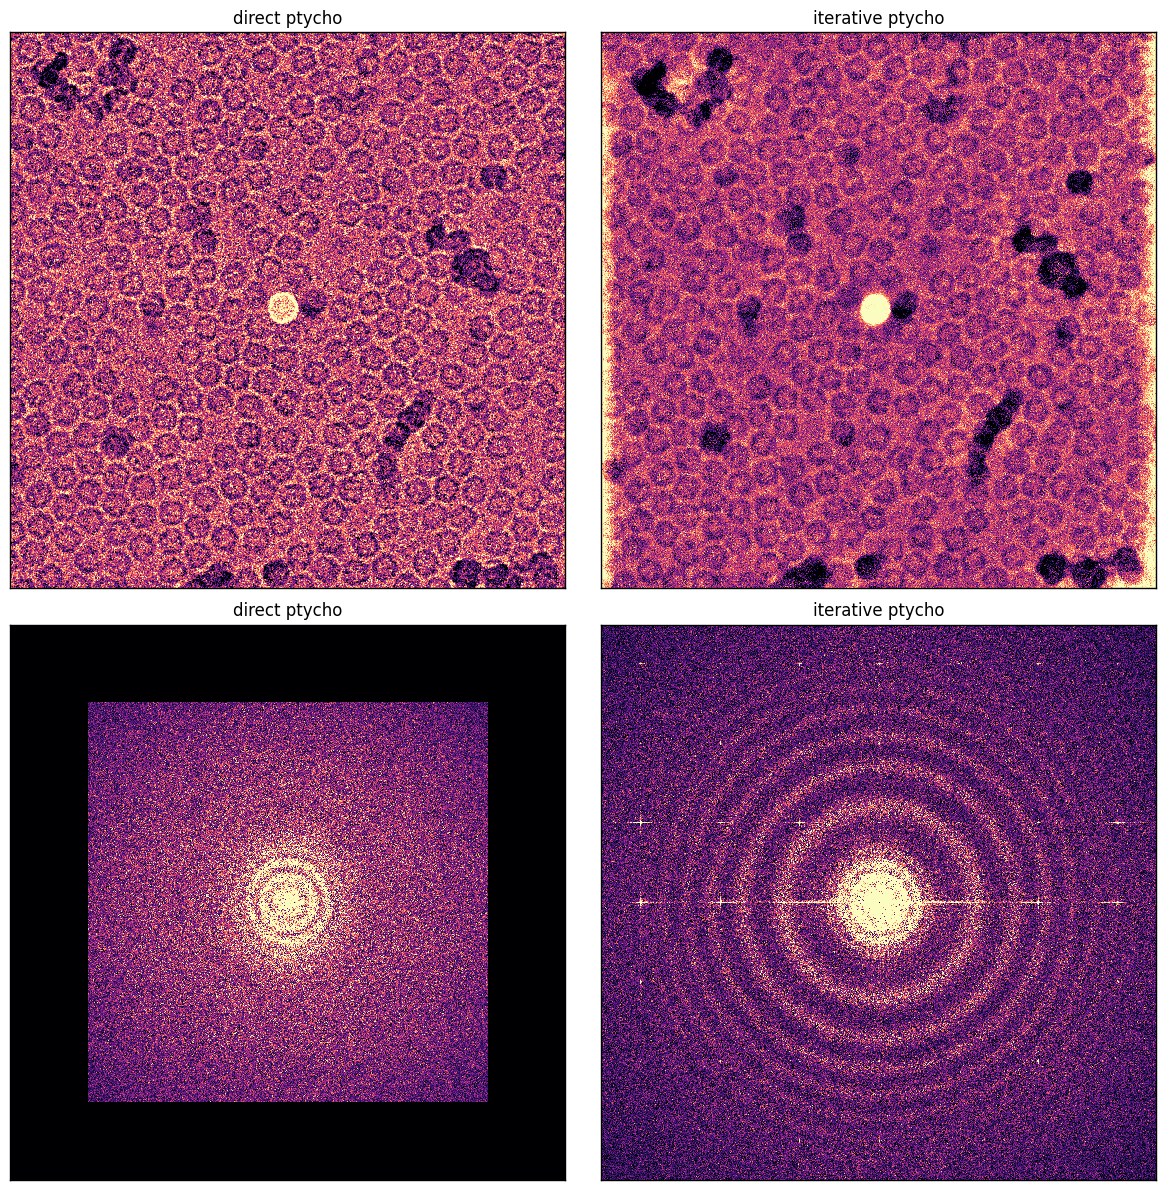

In [22]:
def fft(array):
    return np.abs(np.fft.fftshift(np.fft.fft2(array)))

norm = em.visualization.NormalizationConfig(
    lower_quantile=0.3,
    upper_quantile=0.99
)
 

crop = 40

crop_2 = 400

pad = (ptycho_dip.obj_cropped.shape[1] - initial_parallax.obj.shape[0])//2

show_2d(
    [[
        # dset.virtual_images['DF'].array,
        initial_parallax.obj[crop*2//3:-crop*2//3,crop*2//3:-crop*2//3],
        np.angle(ptycho_dip.obj_cropped[0])[crop:-crop,crop:-crop],
    ],

    [
        # dset.virtual_images['DF'].array,
        np.pad(
            fft(initial_parallax.obj),
            (
                (pad, pad),
                (pad, pad)
            )
        )[crop_2:-crop_2,crop_2:-crop_2],
        fft(np.angle(ptycho_dip.obj_cropped[0]))[crop_2:-crop_2,crop_2:-crop_2],
    ]],
    cmap = "magma",
    title = ["direct ptycho", "iterative ptycho"],
    minmax = None,
    axsize = (6,6),
    # norm = [norm, norm]
)

In [24]:
import h5py
from datetime import datetime

savedir = "recons"

now = datetime.now().strftime("%y%m%d_%H%M")

# Save direct version
with h5py.File(f"{savedir}/{now}_apo_ptycho_direct.h5", 'w') as f:
    print(f)
    f.create_dataset('obj_cropped', data=initial_parallax.obj, compression='gzip')


# Save pixelated version
with h5py.File( f"{savedir}/{now}_apo_ptycho_pix.h5", 'w') as f:
    print(f)
    f.create_dataset('obj_cropped', data=ptycho_pix.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_pix.probe, compression='gzip')
    f.attrs['model_type'] = 'pixelated'

# Save dgp version
with h5py.File(f"{savedir}/{now}_apo_ptycho_dip.h5", 'w') as f:
    f.create_dataset('obj_cropped', data=ptycho_dip.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_dip.probe, compression='gzip')
    f.attrs['model_type'] = 'dgp'

<HDF5 file "251214_1150_apo_ptycho_direct.h5" (mode r+)>
<HDF5 file "251214_1150_apo_ptycho_pix.h5" (mode r+)>


In [26]:
import matplotlib.pyplot as plt

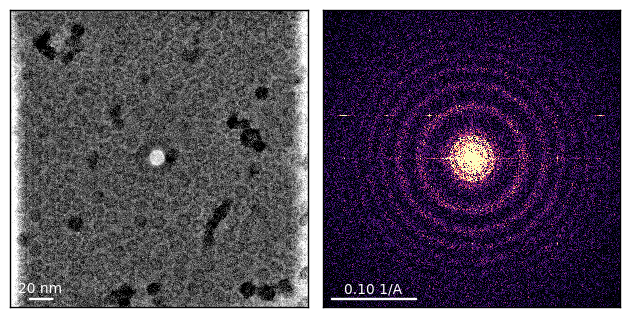

In [32]:
fig, ax = plt.subplots(1,2)

em.visualization.show_2d(
      np.angle(ptycho_dip.obj_cropped).sum(0),
      figax = (fig, ax[0]), 
      scalebar = {
        'sampling':ptycho_dip.sampling[0]/10,
        'units':'nm',
        'length':20,
        'loc':3,   
    }
)


em.visualization.show_2d(
      fft(ptycho_dip.obj_cropped.sum(0))[400:-400,400:-400],
      figax = (fig, ax[1]), 
      scalebar = {
        'sampling':np.fft.fftfreq(ptycho_dip.obj_cropped.shape[1],ptycho_dip.sampling[0])[1],
        'units':'1/A',
        'length':0.1,
        'loc':3,   
     },
     norm = norm,
      cmap = "magma"
)


plt.savefig('apo_iterative_calibration.pdf', bbox_inches = "tight")